# Notebook 3 - Jointure des thèmes LDA et analyses croisées

Ce notebook part des sorties finales produites par les notebooks 1 et 2 :

- `corpus_1993.csv` : base nettoyée, déjà réduite des documents allemands et des textes trop courts ;
- `topics_1993.csv` : sorties de modélisation thématique, notamment les proportions LDA par document.

L'objectif est de joindre les thèmes LDA à la base principale, puis de produire des analyses descriptives interprétables par familles partisanes, sexe du candidat et caractéristiques textuelles.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")
PROC_DIR = DATA_DIR / "processed"
FIGURES_DIR = Path("../figures")
TABLES_DIR = Path("../tables")

FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

CORPUS_CSV = PROC_DIR / "corpus_1993.csv"
TOPICS_CSV = PROC_DIR / "topics_1993.csv"

print("Corpus :", CORPUS_CSV.exists(), CORPUS_CSV)
print("Topics :", TOPICS_CSV.exists(), TOPICS_CSV)


Corpus : True ../data/processed/corpus_1993.csv
Topics : True ../data/processed/topics_1993.csv


## 1. Chargement et jointure

La jointure se fait au niveau du document, avec `id` comme clé. On conserve deux manières d'utiliser les topics :

1. **Thème dominant** : utile pour les tableaux de contingence et les croisements simples.
2. **Proportions LDA** : utiles pour mesurer la prévalence moyenne des thèmes par groupe et les spécialisations relatives.

Le thème dominant ne doit pas remplacer les proportions : il sert surtout à rendre l'analyse lisible.


In [ ]:
df_base = pd.read_csv(CORPUS_CSV)
df_topics = pd.read_csv(TOPICS_CSV)

print("Base :", df_base.shape)
print("Topics :", df_topics.shape)

# Colonnes LDA disponibles
lda_cols = sorted(
    [c for c in df_topics.columns if c.startswith("lda_topic_")],
    key=lambda x: int(x.split("_")[-1])
)

print("Nombre de topics LDA :", len(lda_cols))
print("Colonnes LDA :", lda_cols)

# Sécurité : éviter les doublons
assert df_base["id"].is_unique, "La base principale contient des ids dupliqués."
assert df_topics["id"].is_unique, "La base topics contient des ids dupliqués."

# Jointure
cols_topics = ["id", "lda_dominant_topic", "lda_dominant_label"] + lda_cols
df = df_base.merge(df_topics[cols_topics], on="id", how="left", validate="one_to_one")

# Vérifications
missing_topics = df["lda_dominant_topic"].isna().sum()
print("Documents sans topic LDA après jointure :", missing_topics)

assert missing_topics == 0, "Certains documents n'ont pas reçu de topic LDA."
assert np.allclose(df[lda_cols].sum(axis=1), 1, atol=1e-3), "Les proportions LDA ne somment pas à 1."

print("Base enrichie :", df.shape)
df.head()


Base : (5698, 15)
Topics : (5698, 27)
Nombre de topics LDA : 10
Colonnes LDA : ['lda_topic_0', 'lda_topic_1', 'lda_topic_2', 'lda_topic_3', 'lda_topic_4', 'lda_topic_5', 'lda_topic_6', 'lda_topic_7', 'lda_topic_8', 'lda_topic_9']
Documents sans topic LDA après jointure : 0
Base enrichie : (5698, 27)


,id,titulaire-sexe,titulaire-profession,titulaire-soutien,titulaire-soutien-simplifie,famille_partisane,departement-nom,contexte-tour,raw_text,clean_text_lda,...,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7,lda_topic_8,lda_topic_9
0,EL189_L_1993_03_001_01_1_PF_01,homme,artisan graveur ornemaniste,Front national,Front national,Front national,Ain,1,ELECTIONS LEGISLATIVES DE MARS 93\nFRONT NATIO...,elections legislatives de mars front national ...,...,0.000626,0.000082,0.000100,0.000099,0.000081,0.000296,0.000058,0.876171,0.000267,0.122221
1,EL189_L_1993_03_001_01_1_PF_02,homme,ouvrier Renault Véhicules industriels,Parti communiste français,PCF,PCF,Ain,1,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,république française élections législatives ma...,...,0.032391,0.000053,0.000064,0.055147,0.000052,0.800518,0.000037,0.000098,0.078725,0.032916
2,EL189_L_1993_03_001_01_1_PF_03,homme,non mentionné,Union pour la démocratie française;Rassembleme...,Droite parlementaire (RPR/UDF),Droite parlementaire (RPR/UDF),Ain,1,Sciences Po / fonds CEVIPOF\nElections législa...,elections législatives de mars 1re circonscrip...,...,0.589823,0.000091,0.000111,0.028787,0.000090,0.000329,0.000064,0.000169,0.000297,0.380238
3,EL189_L_1993_03_001_01_1_PF_04,homme,ouvrier métallurgiste,Lutte ouvrière,Extrême gauche,Extrême gauche,Ain,1,Elections législatives du 21 mars 1993\nPourqu...,elections législatives du mars pourquoi voter ...,...,0.000409,0.998625,0.000065,0.000065,0.000053,0.000194,0.000038,0.000100,0.000175,0.000275
4,EL189_L_1993_03_001_01_1_PF_05,homme,professeur économie,Verts;Génération écologie,Écologistes,Écologistes,Ain,1,Sciences Po / fonds CEVIPOF\nRépublique França...,république française département de l ain ere ...,...,0.000956,0.000124,0.552483,0.000150,0.000123,0.000447,0.000088,0.000230,0.444765,0.000634


In [3]:
OUT_FILE = PROC_DIR / "corpus_1993_with_lda_topics.csv"
df.to_csv(OUT_FILE, index=False)
print("Base enrichie sauvegardée :", OUT_FILE)


Base enrichie sauvegardée : ../data/processed/corpus_1993_with_lda_topics.csv


## 2. Distribution générale des thèmes

On commence par observer la distribution des thèmes dominants. Cette lecture donne une première idée des thèmes les plus fréquents dans le corpus, mais elle doit être complétée par les proportions moyennes LDA, car un document peut contenir plusieurs thèmes.


In [4]:
topic_order = (
    df["lda_dominant_label"]
    .value_counts()
    .index
    .tolist()
)

topic_counts = (
    df["lda_dominant_label"]
    .value_counts()
    .rename_axis("topic")
    .reset_index(name="n_documents")
)

topic_counts["share"] = topic_counts["n_documents"] / topic_counts["n_documents"].sum()
topic_counts.to_csv(TABLES_DIR / "03_lda_dominant_topic_distribution.csv", index=False)
topic_counts


,topic,n_documents,share
0,Discours institutionnel et valeurs républicaines,1736,0.304668
1,"Ruralité, agriculture et développement territo...",977,0.171464
2,Mobilisation électorale communiste (PCF),607,0.106529
3,Immigration et fiscalité,584,0.102492
4,"Action locale, solidarité et politiques territ...",473,0.083012
5,"Protection animale, nature et anti-chasse",466,0.081783
6,Écologie politique (Verts / GE),393,0.068972
7,Rapports sociaux et critique du patronat,235,0.041243
8,Services publics et monde ouvrier,131,0.022991
9,Parti de la Loi Naturelle (maharishi védique),96,0.016848


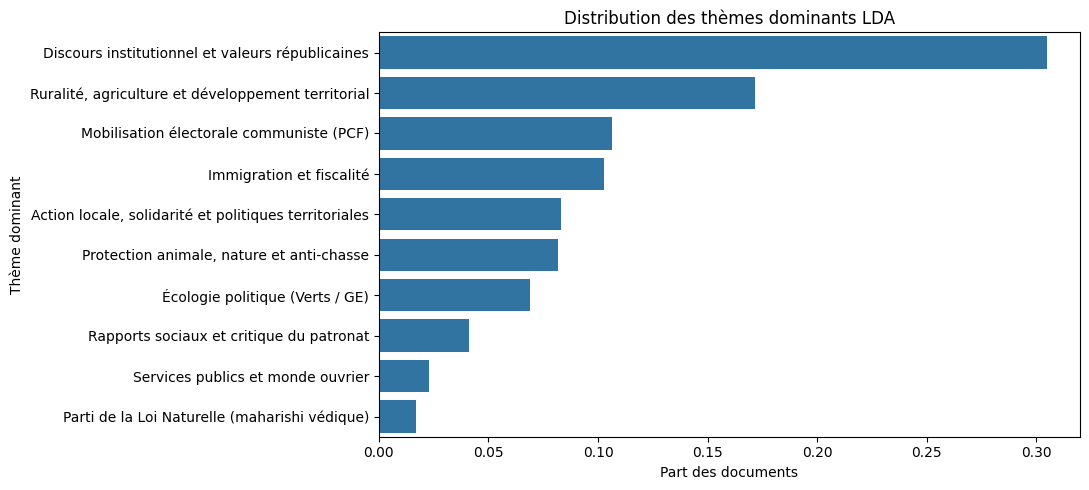

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=topic_counts,
    y="topic",
    x="share",
    ax=ax
)
ax.set_title("Distribution des thèmes dominants LDA")
ax.set_xlabel("Part des documents")
ax.set_ylabel("Thème dominant")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_lda_dominant_topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Croisement thèmes et familles partisanes

La littérature en analyse quantitative des textes politiques recommande de ne pas s'arrêter aux thèmes globaux : il faut regarder comment les thèmes sont distribués selon les groupes politiques. On utilise ici deux indicateurs complémentaires :

- la distribution des **thèmes dominants** par famille partisane ;
- la **prévalence moyenne** de chaque thème par famille partisane, calculée à partir des proportions LDA.


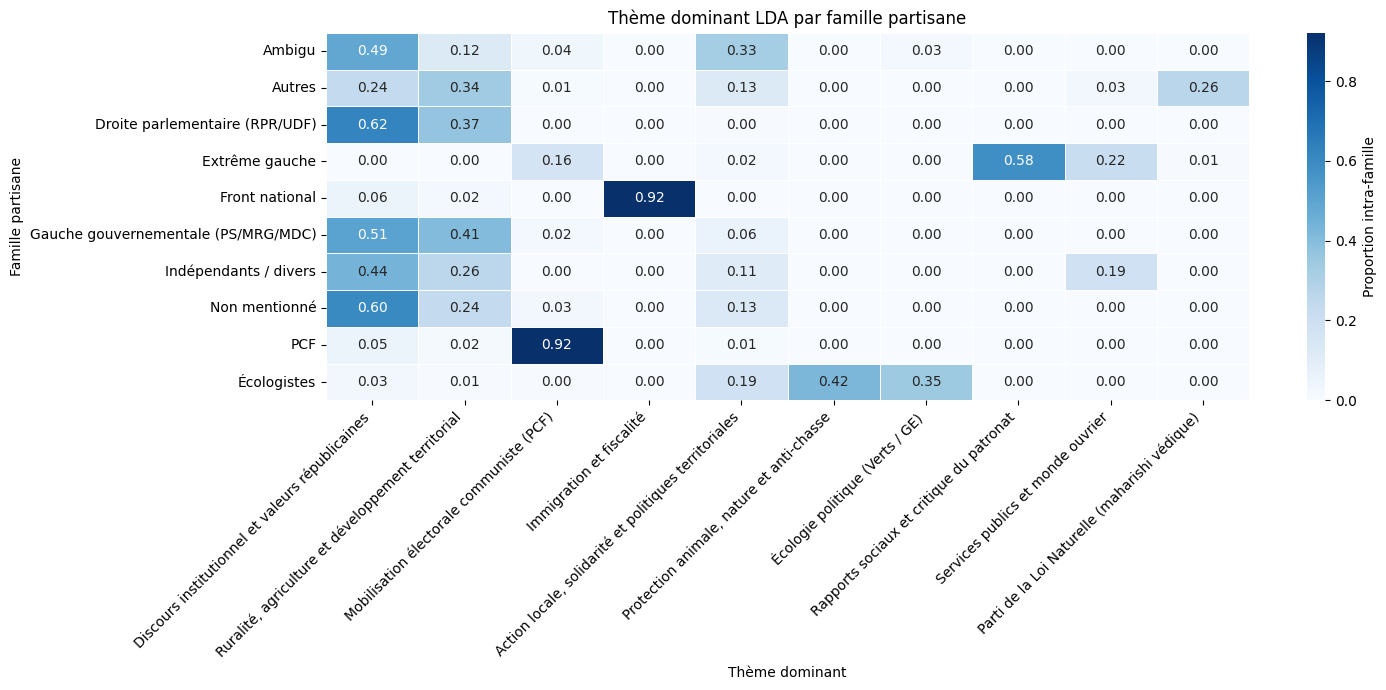

In [6]:
# Thème dominant par famille partisane
party_topic_counts = pd.crosstab(
    df["famille_partisane"],
    df["lda_dominant_label"]
)

party_topic_pct = party_topic_counts.div(party_topic_counts.sum(axis=1), axis=0)
party_topic_pct = party_topic_pct.reindex(columns=topic_order)

party_topic_counts.to_csv(TABLES_DIR / "03_party_by_dominant_topic_counts.csv")
party_topic_pct.to_csv(TABLES_DIR / "03_party_by_dominant_topic_pct.csv")

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    party_topic_pct,
    cmap="Blues",
    linewidths=0.4,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Proportion intra-famille"},
    ax=ax
)
ax.set_title("Thème dominant LDA par famille partisane")
ax.set_xlabel("Thème dominant")
ax.set_ylabel("Famille partisane")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_party_by_dominant_topic_pct.png", dpi=150, bbox_inches="tight")
plt.show()


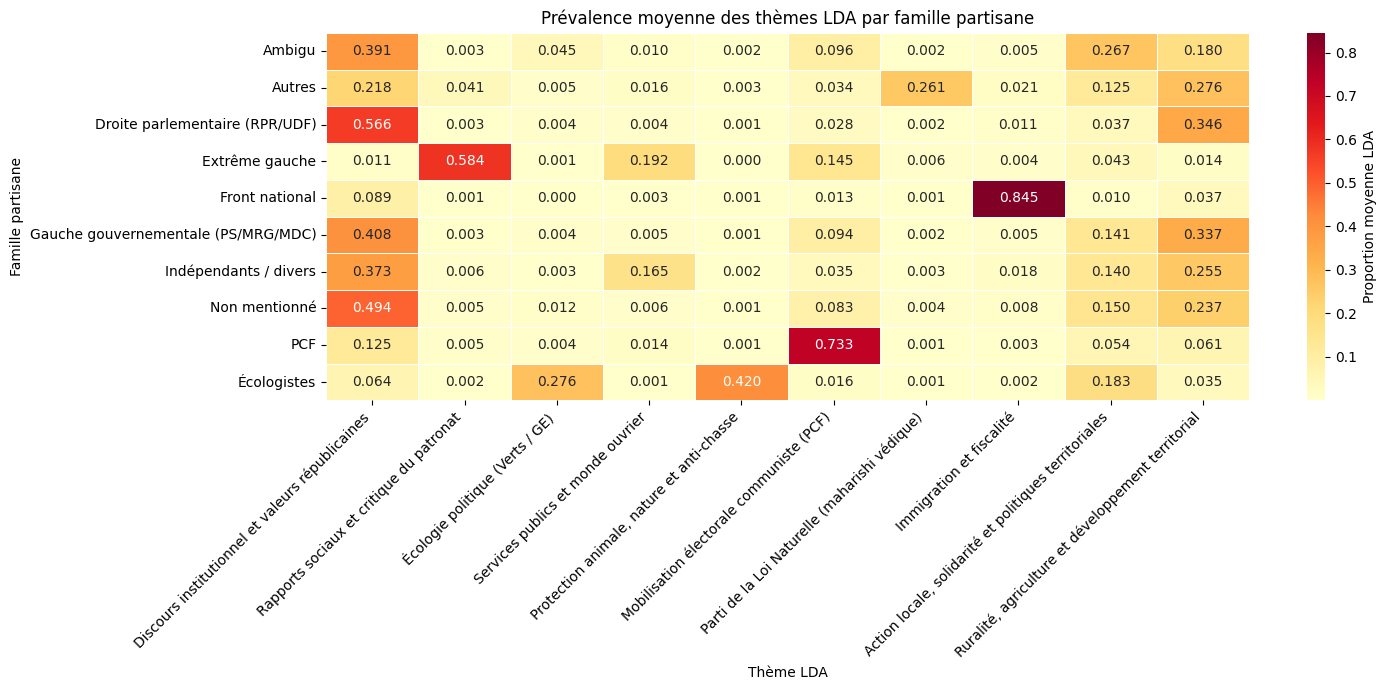

In [7]:
# Prévalence moyenne des thèmes par famille partisane
label_by_col = (
    df_topics[["lda_dominant_topic", "lda_dominant_label"]]
    .drop_duplicates()
    .sort_values("lda_dominant_topic")
    .set_index("lda_dominant_topic")["lda_dominant_label"]
    .to_dict()
)

rename_lda = {
    f"lda_topic_{k}": label_by_col.get(k, f"Topic {k}")
    for k in range(len(lda_cols))
}

party_topic_mean = (
    df.groupby("famille_partisane", observed=True)[lda_cols]
    .mean()
    .rename(columns=rename_lda)
)

party_topic_mean.to_csv(TABLES_DIR / "03_party_topic_mean_proportions.csv")

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    party_topic_mean,
    cmap="YlOrRd",
    linewidths=0.4,
    annot=True,
    fmt=".3f",
    cbar_kws={"label": "Proportion moyenne LDA"},
    ax=ax
)
ax.set_title("Prévalence moyenne des thèmes LDA par famille partisane")
ax.set_xlabel("Thème LDA")
ax.set_ylabel("Famille partisane")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_party_topic_mean_proportions.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Spécialisation thématique des familles partisanes

La moyenne brute indique les thèmes fréquents. Le log-ratio indique plutôt les thèmes qui caractérisent particulièrement une famille politique par rapport à la moyenne du corpus.

Un log-ratio positif signifie que le thème est surreprésenté dans la famille considérée. Un log-ratio négatif signifie qu'il est sous-représenté.


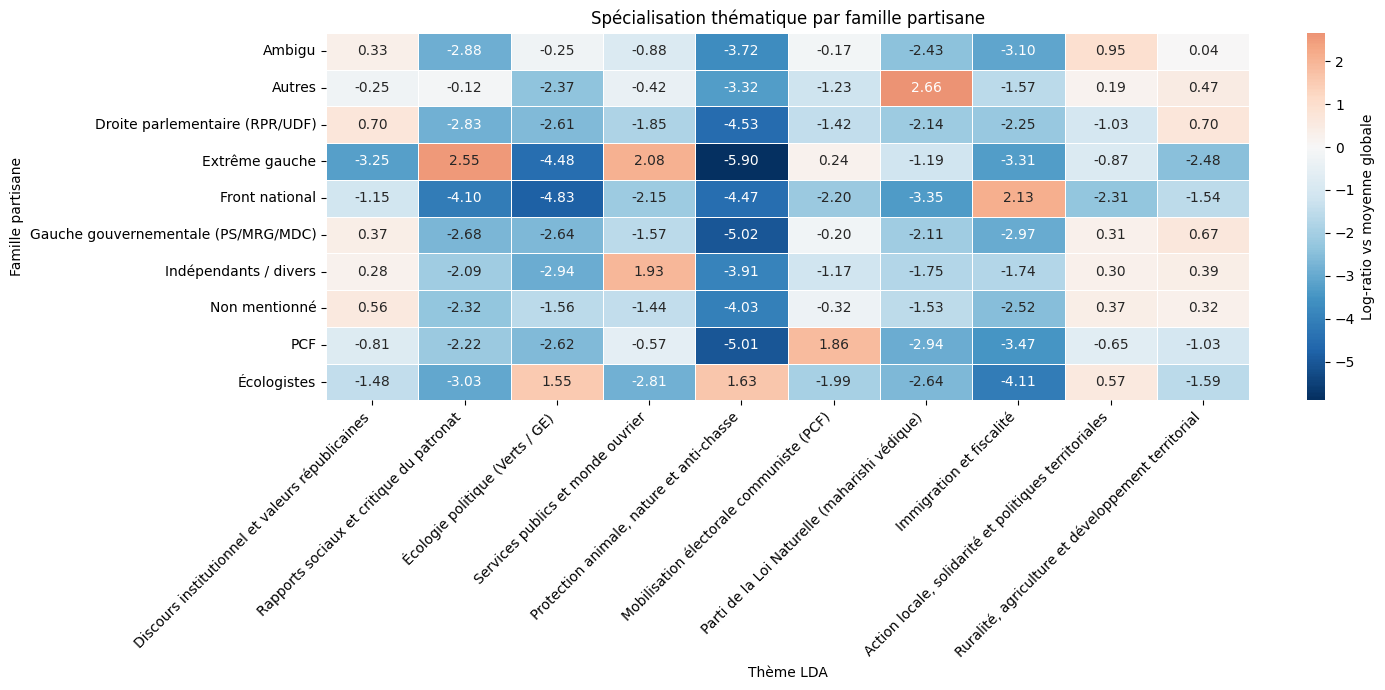

In [8]:
global_topic_mean = df[lda_cols].mean().values
eps = 1e-6

party_topic_lr = np.log((party_topic_mean.values + eps) / (global_topic_mean + eps))
party_topic_lr = pd.DataFrame(
    party_topic_lr,
    index=party_topic_mean.index,
    columns=party_topic_mean.columns
)

party_topic_lr.to_csv(TABLES_DIR / "03_party_topic_logratio_specialisation.csv")

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(
    party_topic_lr,
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Log-ratio vs moyenne globale"},
    ax=ax
)
ax.set_title("Spécialisation thématique par famille partisane")
ax.set_xlabel("Thème LDA")
ax.set_ylabel("Famille partisane")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_party_topic_logratio_specialisation.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Top spécialisations les plus fortes
specialisation_long = (
    party_topic_lr
    .stack()
    .rename("log_ratio")
    .reset_index()
    .rename(columns={"level_0": "famille_partisane", "level_1": "topic"})
)

specialisation_long["over_represented"] = specialisation_long["log_ratio"] > 0

top_specialisations = (
    specialisation_long
    .sort_values("log_ratio", ascending=False)
    .head(20)
)

top_specialisations.to_csv(TABLES_DIR / "03_top_topic_specialisations.csv", index=False)
top_specialisations


,famille_partisane,topic,log_ratio,over_represented
16,Autres,Parti de la Loi Naturelle (maharishi védique),2.661118,True
31,Extrême gauche,Rapports sociaux et critique du patronat,2.545751,True
47,Front national,Immigration et fiscalité,2.134079,True
33,Extrême gauche,Services publics et monde ouvrier,2.084653,True
63,Indépendants / divers,Services publics et monde ouvrier,1.932313,True
85,PCF,Mobilisation électorale communiste (PCF),1.856130,True
94,Écologistes,"Protection animale, nature et anti-chasse",1.627613,True
92,Écologistes,Écologie politique (Verts / GE),1.553705,True
8,Ambigu,"Action locale, solidarité et politiques territ...",0.949604,True
20,Droite parlementaire (RPR/UDF),Discours institutionnel et valeurs républicaines,0.698352,True


## 5. Croisement thèmes et sexe du candidat

Ce croisement est exploratoire. Il permet de voir si certains thèmes dominants apparaissent plus souvent dans les professions de foi selon le sexe du candidat. Cette lecture doit rester prudente, car elle peut être confondue avec les effets de parti.


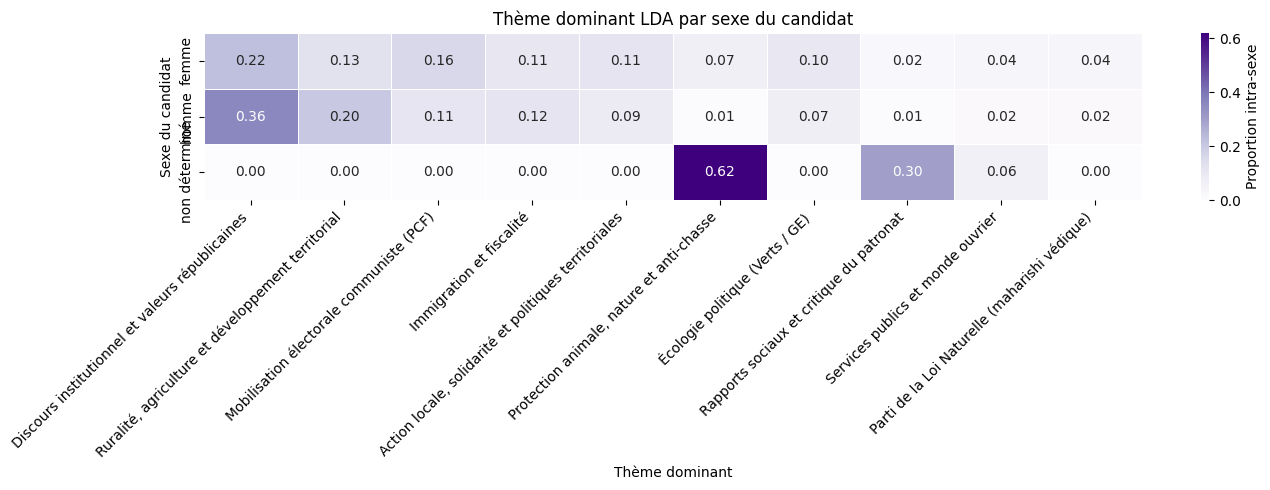

lda_dominant_label,Discours institutionnel et valeurs républicaines,"Ruralité, agriculture et développement territorial",Mobilisation électorale communiste (PCF),Immigration et fiscalité,"Action locale, solidarité et politiques territoriales","Protection animale, nature et anti-chasse",Écologie politique (Verts / GE),Rapports sociaux et critique du patronat,Services publics et monde ouvrier,Parti de la Loi Naturelle (maharishi védique)
titulaire-sexe,,,,,,,,,,
femme,0.223270,0.125786,0.160377,0.108491,0.114780,0.069182,0.102201,0.023585,0.036164,0.036164
homme,0.360081,0.202306,0.113924,0.115732,0.090190,0.005877,0.074141,0.006103,0.015145,0.016501
non déterminé,0.001567,0.003135,0.001567,0.004702,0.001567,0.620690,0.000000,0.302508,0.064263,0.000000


In [10]:
sex_col = "titulaire-sexe"

if sex_col in df.columns:
    sex_topic_counts = pd.crosstab(df[sex_col], df["lda_dominant_label"])
    sex_topic_pct = sex_topic_counts.div(sex_topic_counts.sum(axis=1), axis=0)
    sex_topic_pct = sex_topic_pct.reindex(columns=topic_order)

    sex_topic_counts.to_csv(TABLES_DIR / "03_sex_by_dominant_topic_counts.csv")
    sex_topic_pct.to_csv(TABLES_DIR / "03_sex_by_dominant_topic_pct.csv")

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(
        sex_topic_pct,
        cmap="Purples",
        linewidths=0.4,
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "Proportion intra-sexe"},
        ax=ax
    )
    ax.set_title("Thème dominant LDA par sexe du candidat")
    ax.set_xlabel("Thème dominant")
    ax.set_ylabel("Sexe du candidat")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "03_sex_by_dominant_topic_pct.png", dpi=150, bbox_inches="tight")
    plt.show()

    display(sex_topic_pct)
else:
    print(f"Colonne absente : {sex_col}")


## 6. Netteté thématique des documents

On mesure ici si les documents sont dominés par un thème clair ou s'ils mélangent plusieurs thèmes. Deux indicateurs sont utilisés :

- `lda_topic_max` : poids du thème dominant ;
- `lda_topic_margin` : écart entre les deux thèmes les plus probables.

Un document avec une marge élevée est thématiquement plus net.


In [11]:
theta = df[lda_cols].to_numpy()

df["lda_topic_max"] = theta.max(axis=1)
theta_sorted = np.sort(theta, axis=1)
df["lda_topic_second"] = theta_sorted[:, -2]
df["lda_topic_margin"] = df["lda_topic_max"] - df["lda_topic_second"]

clarity_summary = (
    df.groupby("lda_dominant_label")[["lda_topic_max", "lda_topic_margin"]]
    .agg(["mean", "median", "count"])
    .sort_values(("lda_topic_max", "mean"), ascending=False)
)

clarity_summary.to_csv(TABLES_DIR / "03_topic_clarity_summary.csv")
clarity_summary


lda_topic_max            \
                                                            mean    median   
lda_dominant_label                                                           
Rapports sociaux et critique du patronat                0.998538  0.998622   
Protection animale, nature et anti-chasse               0.994230  0.994477   
Parti de la Loi Naturelle (maharishi védique)           0.966984  0.998344   
Immigration et fiscalité                                0.901653  0.994783   
Services publics et monde ouvrier                       0.760962  0.824537   
Mobilisation électorale communiste (PCF)                0.757538  0.781029   
Écologie politique (Verts / GE)                         0.730368  0.739084   
Discours institutionnel et valeurs républicaines        0.686728  0.676455   
Ruralité, agriculture et développement territorial      0.606968  0.578568   
Action locale, solidarité et politiques territo...      0.600371  0.570063   

                                                         lda_topic_margin  \
                                                   count             mean   
lda_dominant_label                                                          
Rapports sociaux et critique du patronat             235         0.998073   
Protection animale, nature et anti-chasse            466         0.992437   
Parti de la Loi Naturelle (maharishi védique)         96         0.948130   
Immigration et fiscalité                             584         0.825387   
Services publics et monde ouvrier                    131         0.633969   
Mobilisation électorale communiste (PCF)             607         0.597454   
Écologie politique (Verts / GE)                      393         0.540928   
Discours institutionnel et valeurs républicaines    1736         0.471826   
Ruralité, agriculture et développement territorial   977         0.342634   
Action locale, solidarité et politiques territo...   473         0.363914   

                                                                    
                                                      median count  
lda_dominant_label                                                  
Rapports sociaux et critique du patronat            0.998212   235  
Protection animale, nature et anti-chasse           0.992836   466  
Parti de la Loi Naturelle (maharishi védique)       0.997855    96  
Immigration et fiscalité                            0.990914   584  
Services publics et monde ouvrier                   0.695607   131  
Mobilisation électorale communiste (PCF)            0.634177   607  
Écologie politique (Verts / GE)                     0.558207   393  
Discours institutionnel et valeurs républicaines    0.450707  1736  
Ruralité, agriculture et développement territorial  0.284627   977  
Action locale, solidarité et politiques territo...  0.304834   473

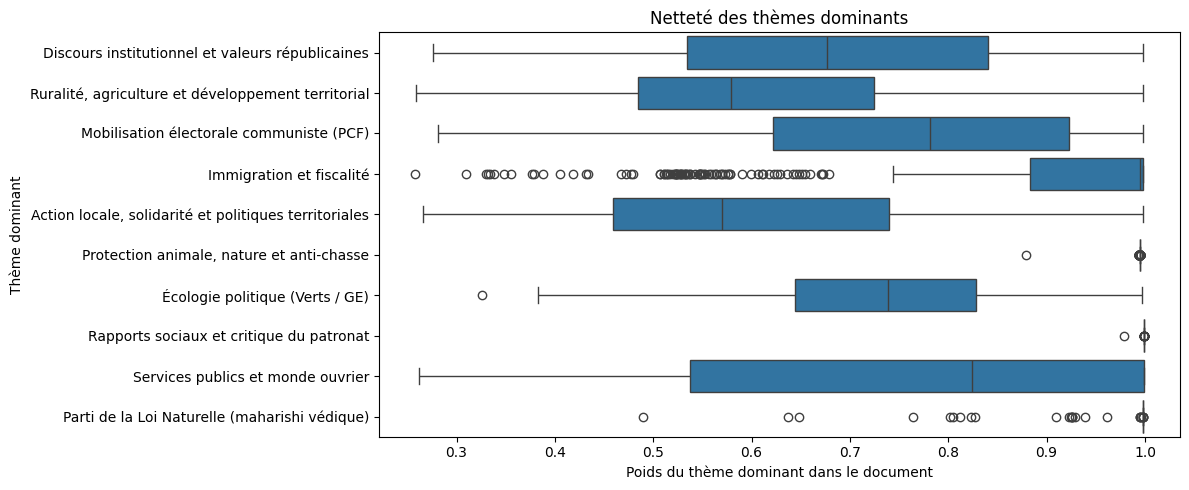

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df,
    x="lda_topic_max",
    y="lda_dominant_label",
    order=topic_order,
    ax=ax
)
ax.set_title("Netteté des thèmes dominants")
ax.set_xlabel("Poids du thème dominant dans le document")
ax.set_ylabel("Thème dominant")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_topic_clarity_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Variables textuelles et thèmes

On croise les thèmes avec les caractéristiques textuelles disponibles : longueur, nombre de tokens et richesse lexicale. Cela permet d'identifier si certains thèmes correspondent à des professions de foi plus longues, plus courtes ou lexicalement plus diversifiées.


Métriques disponibles : ['n_chars_raw', 'n_words_lda', 'n_tokens', 'msttr']


n_chars_raw          \
                                                           mean  median   
lda_dominant_label                                                        
Action locale, solidarité et politiques territo...  5122.997886  5029.0   
Discours institutionnel et valeurs républicaines    3201.668779  2766.5   
Immigration et fiscalité                            5308.756849  5417.0   
Mobilisation électorale communiste (PCF)            4649.301483  4632.0   
Parti de la Loi Naturelle (maharishi védique)       4882.833333  5377.0   
Protection animale, nature et anti-chasse           1713.811159  1715.0   
Rapports sociaux et critique du patronat            7443.234043  7439.0   
Ruralité, agriculture et développement territorial  4370.099284  4028.0   
Services publics et monde ouvrier                   5403.755725  5723.0   
Écologie politique (Verts / GE)                     3522.498728  3436.0   

                                                                       \
                                                            std count   
lda_dominant_label                                                      
Action locale, solidarité et politiques territo...  1952.506495   473   
Discours institutionnel et valeurs républicaines    1655.709662  1736   
Immigration et fiscalité                             730.482316   584   
Mobilisation électorale communiste (PCF)            1528.574267   607   
Parti de la Loi Naturelle (maharishi védique)       1394.618029    96   
Protection animale, nature et anti-chasse             23.364129   466   
Rapports sociaux et critique du patronat              12.518726   235   
Ruralité, agriculture et développement territorial  1951.586721   977   
Services publics et monde ouvrier                   1587.715868   131   
Écologie politique (Verts / GE)                      691.709628   393   

                                                    n_words_lda          \
                                                           mean  median   
lda_dominant_label                                                        
Action locale, solidarité et politiques territo...   796.926004   778.0   
Discours institutionnel et valeurs républicaines     506.173963   435.5   
Immigration et fiscalité                             841.409247   865.0   
Mobilisation électorale communiste (PCF)             755.016474   753.0   
Parti de la Loi Naturelle (maharishi védique)        750.989583   825.0   
Protection animale, nature et anti-chasse            242.538627   243.0   
Rapports sociaux et critique du patronat            1295.548936  1295.0   
Ruralité, agriculture et développement territorial   679.131013   630.0   
Services publics et monde ouvrier                    872.328244   934.0   
Écologie politique (Verts / GE)                      537.623410   525.0   

                                                                      \
                                                           std count   
lda_dominant_label                                                     
Action locale, solidarité et politiques territo...  311.913845   473   
Discours institutionnel et valeurs républicaines    270.841791  1736   
Immigration et fiscalité                            123.123062   584   
Mobilisation électorale communiste (PCF)            251.067161   607   
Parti de la Loi Naturelle (maharishi védique)       217.039676    96   
Protection animale, nature et anti-chasse             3.273814   466   
Rapports sociaux et critique du patronat              1.943856   235   
Ruralité, agriculture et développement territorial  314.215369   977   
Services publics et monde ouvrier                   263.257827   131   
Écologie politique (Verts / GE)                     112.037192   393   

                                                      n_tokens         \
                                                          mean median   
lda_dominant_label                                                 

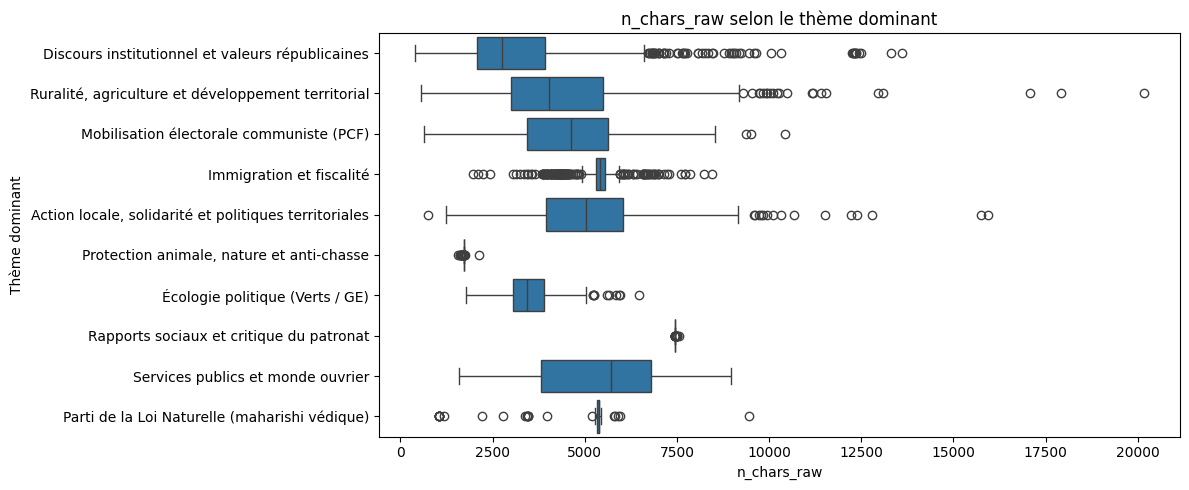

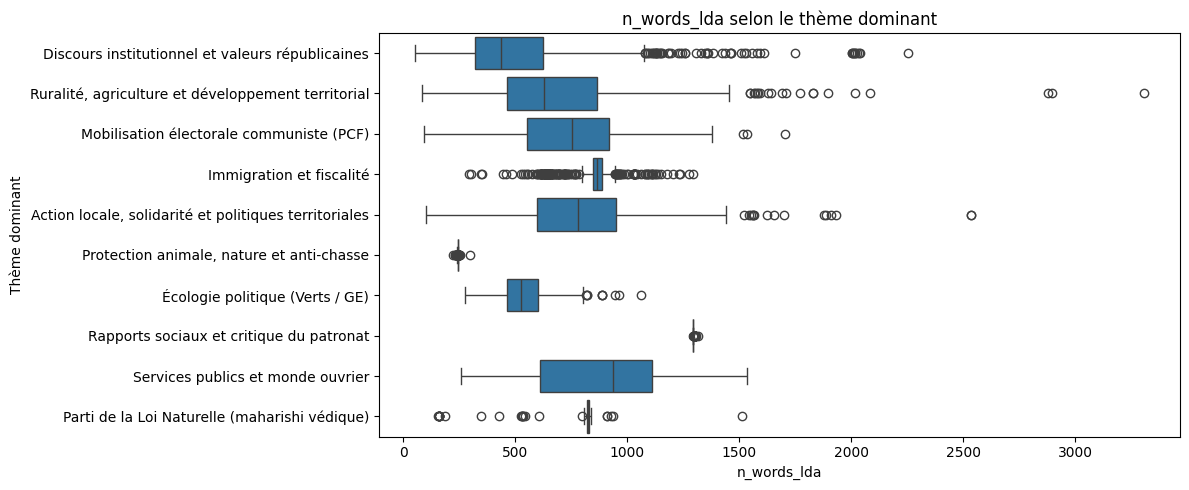

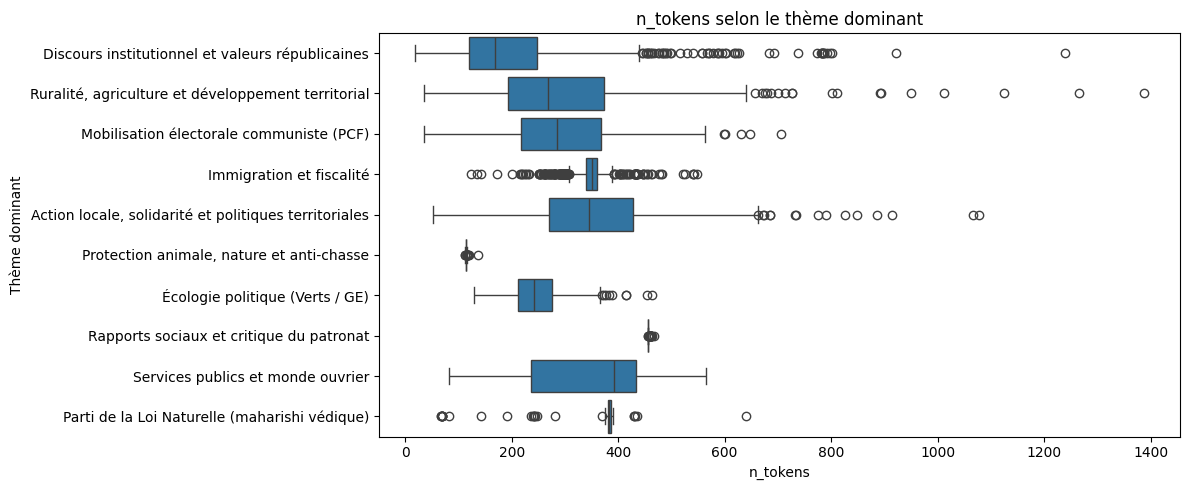

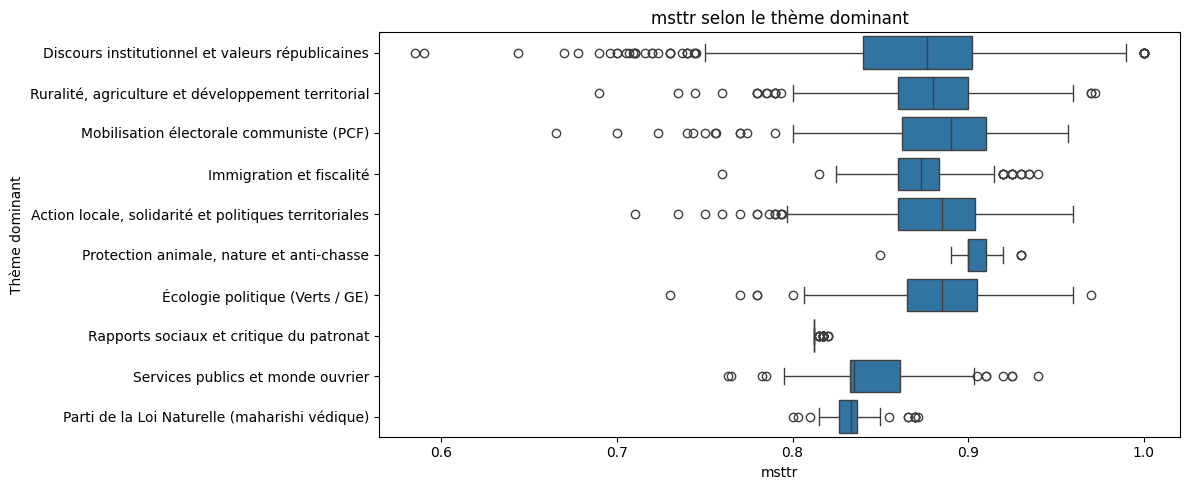

In [13]:
candidate_metrics = [
    "n_chars_raw", "n_words_lda", "n_words_emb", "n_tokens", "msttr"
]

metrics = [c for c in candidate_metrics if c in df.columns]
print("Métriques disponibles :", metrics)

if metrics:
    topic_text_stats = (
        df.groupby("lda_dominant_label")[metrics]
        .agg(["mean", "median", "std", "count"])
    )
    topic_text_stats.to_csv(TABLES_DIR / "03_topic_textual_statistics.csv")
    display(topic_text_stats)

    for metric in metrics:
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.boxplot(
            data=df,
            x=metric,
            y="lda_dominant_label",
            order=topic_order,
            ax=ax
        )
        ax.set_title(f"{metric} selon le thème dominant")
        ax.set_xlabel(metric)
        ax.set_ylabel("Thème dominant")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"03_{metric}_by_topic.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("Aucune métrique textuelle disponible dans la base.")


## 8. Synthèse automatique des principaux résultats

Cette cellule produit quelques phrases descriptives utiles pour orienter la rédaction du rapport.


In [ ]:
print("SYNTHÈSE DESCRIPTIVE")
print("-" * 70)

main_topic = topic_counts.iloc[0]
print(f"Thème dominant le plus fréquent : {main_topic['topic']} ({main_topic['share']:.1%} des documents).")

print("\nTop 10 spécialisations partisanes :")
for _, row in top_specialisations.head(10).iterrows():
    print(f"- {row['famille_partisane']} : {row['topic']} (log-ratio = {row['log_ratio']:.2f})")

if "lda_topic_max" in df.columns:
    print("\nNetteté thématique moyenne :")
    print(f"- poids moyen du thème dominant : {df['lda_topic_max'].mean():.3f}")
    print(f"- marge moyenne entre 1er et 2e thème : {df['lda_topic_margin'].mean():.3f}")

if sex_col in df.columns:
    print("\nRépartition par sexe disponible :")
    print(df[sex_col].value_counts(dropna=False).to_string())


SYNTHÈSE DESCRIPTIVE
----------------------------------------------------------------------
Thème dominant le plus fréquent : Discours institutionnel et valeurs républicaines (30.5% des documents).

Top 10 spécialisations partisanes :
- Autres : Parti de la Loi Naturelle (maharishi védique) (log-ratio = 2.66)
- Extrême gauche : Rapports sociaux et critique du patronat (log-ratio = 2.55)
- Front national : Immigration et fiscalité (log-ratio = 2.13)
- Extrême gauche : Services publics et monde ouvrier (log-ratio = 2.08)
- Indépendants / divers : Services publics et monde ouvrier (log-ratio = 1.93)
- PCF : Mobilisation électorale communiste (PCF) (log-ratio = 1.86)
- Écologistes : Protection animale, nature et anti-chasse (log-ratio = 1.63)
- Écologistes : Écologie politique (Verts / GE) (log-ratio = 1.55)
- Ambigu : Action locale, solidarité et politiques territoriales (log-ratio = 0.95)
- Droite parlementaire (RPR/UDF) : Discours institutionnel et valeurs républicaines (log-ratio = 0.7

## 9. Sauvegarde finale

La base enrichie est sauvegardée avec les thèmes LDA, les proportions par thème et les indicateurs de netteté thématique.


In [15]:
OUT_FILE_FINAL = PROC_DIR / "corpus_1993_with_lda_topics_and_descriptors.csv"
df.to_csv(OUT_FILE_FINAL, index=False)
print("Sauvegarde finale :", OUT_FILE_FINAL)
print("Dimensions :", df.shape)


Sauvegarde finale : ../data/processed/corpus_1993_with_lda_topics_and_descriptors.csv
Dimensions : (5698, 30)
